<h1><strong>Linear Regression</strong></h1>

Linear regression is one of the most important algorithm in machine learning and statistics. It helps us to understand the relationship between variables and predict continues values.

<strong>Example</strong>

- Predict house prices
- Predict salary based on experience
- Predict sales revenue
- Predict temperature trends

Linear regression tries to fit a straight line through data points.

y = mx + C

<h2><strong>Types of Linear Regression</strong></h2>

- Simple Linear regression

    One input feature: Height vs Weight, Salary vs Experience

- Multiple Linear Regression

    Multiple Input feature.
        
        - House Price Prediction
            
            - area
            - bedrooms
            - location score

<h2><strong>Terminologies</strong></h2>

|Term | Meaning|
|------|-------|
|Feature|Input variables|
|Target|Output variables|
|Coefficient|Weight of feature|
|Intercept|starting point|
|Residual|Actual-Predict|
|Prediction|Model output|

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.array([1,2,3,4,5])
y = np.array([2,4,5,4,5])

In [3]:
x_mean = np.mean(x)
y_mean = np.mean(y)

print(f"x mean: {x_mean}, y mean: {y_mean}")

x mean: 3.0, y mean: 4.0


In [4]:
numerator = np.sum((x-x_mean)*(y-y_mean))
denominator = np.sum((x-x_mean)**2)

m = numerator / denominator

print("Slope: ",m)

Slope:  0.6


In [5]:
b = y_mean - m * x_mean

print("Intercept",b)

Intercept 2.2


In [8]:
y_pred = m * x + b

In [9]:
y_pred

array([2.8, 3.4, 4. , 4.6, 5.2])

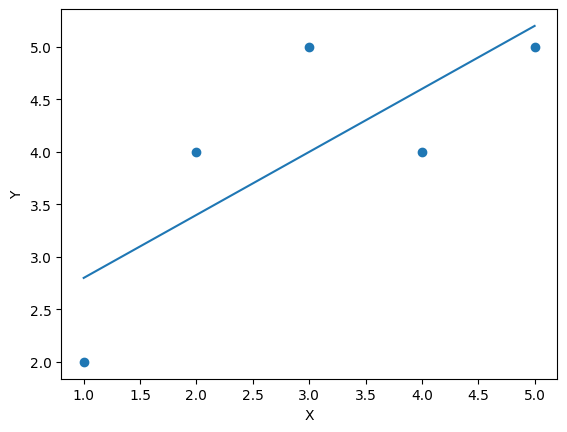

In [10]:
plt.scatter(x,y,label='Actual data points')
plt.plot(x,y_pred,label="Regressoin line")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [12]:
residual = np.sum((y - y_pred)**2) / 5

In [14]:
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [17]:
housing = fetch_california_housing()
df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df['Price'] = housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [18]:
X = df[['MedInc']] # x must be 2D dataframe/array
y = df['Price']#y should be 1D

In [19]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
linear = LinearRegression()
model = linear.fit(X_train,y_train)

In [21]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test,y_pred)

print("MAE: ",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2 Score:",r2)

MAE:  0.629908653009376
MSE: 0.7091157771765548
RMSE: 0.8420901241414454
R2 Score: 0.45885918903846656


In [24]:
model.coef_

array([0.41933849])

In [25]:
model.intercept_

np.float64(0.44459729169078677)

<h2><strong>Multiple Linear Regression</strong></h2>

In [28]:
X = df.drop('Price',axis=1)
y= df['Price']

In [29]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [30]:
linear = LinearRegression()
model = linear.fit(X_train,y_train)

In [31]:
y_pred = model.predict(X_test)

In [32]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test,y_pred)

print("MAE: ",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2 Score:",r2)

MAE:  0.5332001304956548
MSE: 0.5558915986952444
RMSE: 0.7455813830127764
R2 Score: 0.5757877060324508


In [33]:
y_test

20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
          ...   
15362    2.63300
16623    2.66800
18086    5.00001
2144     0.72300
3665     1.51500
Name: Price, Length: 4128, dtype: float64

In [34]:
y_pred

array([0.71912284, 1.76401657, 2.70965883, ..., 4.46877017, 1.18751119,
       2.00940251], shape=(4128,))